# Gated Recurrent Unit (GRU) - 2nd RNN Variant

Gated Recurrent Unit (GRU) which has only 2 gates, **reset gate and update gate (a combination of the forget and input gates)**. This helps in increasing the performance by reducing the number of gradients to be computed.

## What is GRU?

The Gated Recurrent Unit or simply, GRU is a new version of LSTM, which is gaining a lot of popularity these days. It is because of the simpler design in terms of the number of update equations, resulting in shorter training times.

### The GRU achieves this simpler design because of the following points –

   - It combines Input and Forget gate into a single Update gate.
   - There is no output activation function.
   - Output gate (called Reset gate here) only gates the recurrent connections to block input.
   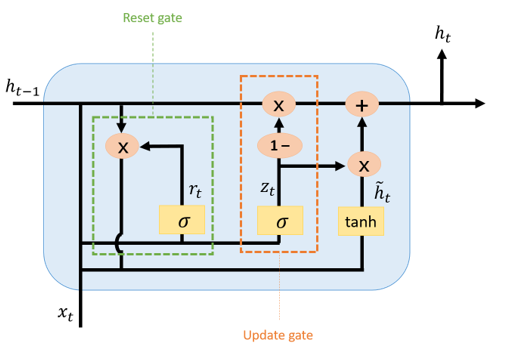

From the above figure, the governing equations can be written as follow –

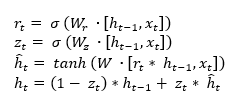

## Building a GRU model to perform the above steps used to create LSTM model.

### Installing Packages

In [1]:
%pip install numpy matplotlib keras tensorflow scikit-learn


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Importing Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, LSTM, Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

2025-06-16 18:33:08.248919: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-16 18:33:08.253007: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-16 18:33:08.262537: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750098788.277580   24287 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750098788.282171   24287 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1750098788.295138   24287 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

### Preparing Data

In [3]:
# Generate dummy time series data
t = np.linspace(0, 100, 1000)
data = np.sin(t)

# Normalize data
scaler = MinMaxScaler()
data = scaler.fit_transform(data.reshape(-1, 1)).flatten()

# Create sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 20
X, y = create_sequences(data, seq_length)
X = X[..., np.newaxis]  # Add feature dimension

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

### Building models

In [4]:
# GRU Model
gru_model = Sequential([
    GRU(50, input_shape=(seq_length, 1)),
    Dense(1)
])
gru_model.compile(optimizer='adam', loss='mse')

# LSTM Model for comparison
lstm_model = Sequential([
    LSTM(50, input_shape=(seq_length, 1)),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')

2025-06-16 18:33:11.933293: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Training models

In [5]:
# Train GRU
history_gru = gru_model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1, verbose=0)

# Train LSTM
history_lstm = lstm_model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1, verbose=0)

### Evaluate & Comparision

GRU Test Loss: 0.0000
LSTM Test Loss: 0.0000


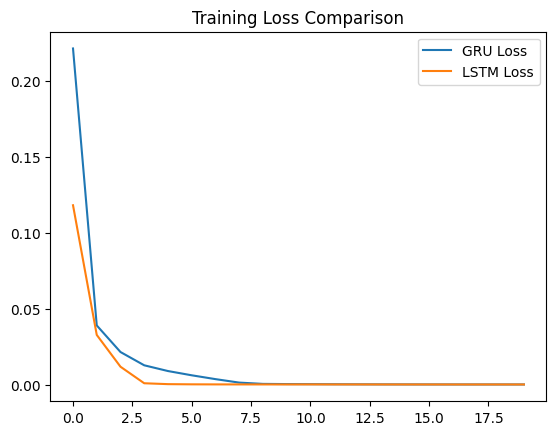

In [6]:
# Evaluate
gru_loss = gru_model.evaluate(X_test, y_test, verbose=0)
lstm_loss = lstm_model.evaluate(X_test, y_test, verbose=0)

print(f"GRU Test Loss: {gru_loss:.4f}")
print(f"LSTM Test Loss: {lstm_loss:.4f}")

# Plot training loss
plt.plot(history_gru.history['loss'], label='GRU Loss')
plt.plot(history_lstm.history['loss'], label='LSTM Loss')
plt.legend()
plt.title('Training Loss Comparison')
plt.show()